<a href="https://colab.research.google.com/github/Simran-Dalvi/Real_Estate_Price_Prediction_End_to_End/blob/main/banglore_house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load the Data

To see how to use kaggle on git hub see [source](https://github.com/Kaggle/kagglehub/blob/main/README.md#download-dataset).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
# Load a DataFrame with a specific version of a CSV
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "amitabhajoy/bengaluru-house-price-data",
    "Bengaluru_House_Data.csv"
)

100%|██████████| 916k/916k [00:00<00:00, 2.87MB/s]


In [4]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [5]:
df.shape

(13320, 9)

# Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


size should be a number, total_sqft should be a number.

In [7]:
df.groupby('area_type')['area_type'].agg('count')

,area_type
area_type,
Built-up Area,2418
Carpet Area,87
Plot Area,2025
Super built-up Area,8790


In [8]:
# Drop columns which would not help in machine learning
df_droped = df.drop(['area_type', 'availability', 'society', 'balcony'], axis = 1)
df_droped.shape

(13320, 5)

In [9]:
df_droped.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [10]:
df_droped.isnull().sum()

,0
location,1
size,16
total_sqft,0
bath,73
price,0


In [11]:
# Since the data is big i'll just delete all the cols that are null.
df_nonna = df_droped.dropna()
df_nonna.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [12]:
df_droped.shape[0], df_nonna.shape[0]

(13320, 13246)

In [13]:
df_nonna['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

 our regression model would not understand this...

In [14]:
df_nonna['bhk'] = df_nonna['size'].apply(lambda x: int(x.split(' ')[0]))

/tmp/ipykernel_402/111542672.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nonna['bhk'] = df_nonna['size'].apply(lambda x: int(x.split(' ')[0]))


In [15]:
df_nonna = df_nonna.drop(['size'], axis = 1)
df_nonna.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056,2.0,39.07,2
1,Chikka Tirupathi,2600,5.0,120.00,4
2,Uttarahalli,1440,2.0,62.00,3
3,Lingadheeranahalli,1521,3.0,95.00,3
4,Kothanur,1200,2.0,51.00,2


In [16]:
df_nonna['bhk'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [17]:
df_nonna[df_nonna['bhk'] > 20]

,location,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,8000,27.0,230.0,27
4684,Munnekollal,2400,40.0,660.0,43


Looks like an error in data.

A 23 room house has 8k sq_ft area... but a 43 roomed house has only 2.4k.

In [18]:
# Let's see what our total_sqft looks like
df_nonna['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

`1133- 1348` is not a number, so thats why it was an object datatype.

In [19]:
# Function to check and convert our total_sqft col
def is_float(x):
  try :
    float(x)
  except:
    return False
  return True

In [20]:
#  all columns that cannot be converted to float values
df_nonna[~df_nonna['total_sqft'].apply(is_float)].head(20)

,location,total_sqft,bath,price,bhk
30,Yelahanka,2100 - 2850,4.0,186.000,4
122,Hebbal,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,43.490,2
188,KR Puram,1015 - 1540,2.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,63.770,2
648,Arekere,4125Perch,9.0,265.000,9
661,Yelahanka,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,445.000,4


In [21]:
#  Function to convert values in range
def convert_sqft_To_num(x):
  tokens = x.split(' - ')
  if len(tokens) == 2:
    return (float(tokens[0]) + float(tokens[1])) / 2
  try :
    return float(x)
  except:
    return None

In [22]:
df_area = df_nonna.copy()

In [23]:
df_area['total_sqft'] = df_area['total_sqft'].apply(convert_sqft_To_num)
df_area.head(50)

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.00,2.0,39.07,2
1,Chikka Tirupathi,2600.00,5.0,120.00,4
2,Uttarahalli,1440.00,2.0,62.00,3
3,Lingadheeranahalli,1521.00,3.0,95.00,3
4,Kothanur,1200.00,2.0,51.00,2
5,Whitefield,1170.00,2.0,38.00,2
6,Old Airport Road,2732.00,4.0,204.00,4
7,Rajaji Nagar,3300.00,4.0,600.00,4
8,Marathahalli,1310.00,3.0,63.25,3
9,Gandhi Bazar,1020.00,6.0,370.00,6


In [24]:
df_area.loc[410]

,410
location,Kengeri
total_sqft,NaN
bath,1.0
price,18.5
bhk,1


In [25]:
df_area.isnull().sum()

,0
location,0
total_sqft,46
bath,0
price,0
bhk,0


Still we have 46 rows with no area in them.

# Feature Engineering

In [26]:
df_price = df_area.copy()

In [27]:
# since data is in lakh multiply with 100000 and divide by total area
df_price['price_per_sqft'] = round((df_price['price'] * 1e5) / df_price['total_sqft'], 2)
df_price.head()

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.81
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.38
2,Uttarahalli,1440.0,2.0,62.00,3,4305.56
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.89
4,Kothanur,1200.0,2.0,51.00,2,4250.00


In [28]:
len(df_price['location'].unique())

1304

In [29]:
df_price.shape

(13246, 6)

There are about 1300 unique locations in our data.

Working with these data for machine learning will have to one-hot encode them and having only 13000 rows will have a problem called `The curse of dimensionality`.

So we will try to take only the names of the common locations and drop the rest in "other" location.

In [30]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13246 non-null  object 
 1   total_sqft      13200 non-null  float64
 2   bath            13246 non-null  float64
 3   price           13246 non-null  float64
 4   bhk             13246 non-null  int64  
 5   price_per_sqft  13200 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.2+ MB


In [31]:
# Strip data of any spaces
df_price['location'] = df_price['location'].apply(lambda x : x.strip())
df_price.head()

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.81
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.38
2,Uttarahalli,1440.0,2.0,62.00,3,4305.56
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.89
4,Kothanur,1200.0,2.0,51.00,2,4250.00


In [32]:
location_stats = df_price.groupby('location')['location'].agg('count').sort_values(ascending = False)
location_stats

,location
location,
Whitefield,535
Sarjapur Road,392
Electronic City,304
Kanakpura Road,266
Thanisandra,236
...,...
poornaprajna layout,1
pavitra paradise,1
near Ramanashree California resort,1


In [33]:
len(location_stats[location_stats <= 10])

1052

In [34]:
location_stats_less_than_10 = location_stats[ location_stats <= 10]
location_stats_less_than_10

,location
location,
Kalkere,10
Sadashiva Nagar,10
BTM 1st Stage,10
Basapura,10
Gunjur Palya,10
...,...
poornaprajna layout,1
pavitra paradise,1
near Ramanashree California resort,1


In [35]:
df_price['location'] = df_price['location'].apply(lambda x: 'Other' if x in location_stats_less_than_10 else x)
len(df_price['location'].unique())

242

In [36]:
df_price.head(15)

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.81
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.38
2,Uttarahalli,1440.0,2.0,62.00,3,4305.56
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.89
4,Kothanur,1200.0,2.0,51.00,2,4250.00
5,Whitefield,1170.0,2.0,38.00,2,3247.86
6,Old Airport Road,2732.0,4.0,204.00,4,7467.06
7,Rajaji Nagar,3300.0,4.0,600.00,4,18181.82
8,Marathahalli,1310.0,3.0,63.25,3,4828.24
9,Other,1020.0,6.0,370.00,6,36274.51


# Outlier Removal

In [37]:
df_price

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.81
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.38
2,Uttarahalli,1440.0,2.0,62.00,3,4305.56
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.89
4,Kothanur,1200.0,2.0,51.00,2,4250.00
...,...,...,...,...,...,...
13315,Whitefield,3453.0,4.0,231.00,5,6689.83
13316,Other,3600.0,5.0,400.00,4,11111.11
13317,Raja Rajeshwari Nagar,1141.0,2.0,60.00,2,5258.55
13318,Padmanabhanagar,4689.0,4.0,488.00,4,10407.34


In [38]:
# Remove data where area per room is below 300 sq.ft.
df1 = df_price[~((df_price.total_sqft / df_price.bhk) < 300)]
df1

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.81
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.38
2,Uttarahalli,1440.0,2.0,62.00,3,4305.56
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.89
4,Kothanur,1200.0,2.0,51.00,2,4250.00
...,...,...,...,...,...,...
13315,Whitefield,3453.0,4.0,231.00,5,6689.83
13316,Other,3600.0,5.0,400.00,4,11111.11
13317,Raja Rajeshwari Nagar,1141.0,2.0,60.00,2,5258.55
13318,Padmanabhanagar,4689.0,4.0,488.00,4,10407.34


In [39]:
# Check price per total area
df1.price_per_sqft.describe()

,price_per_sqft
count,12456.000000
mean,6308.502836
std,4168.127366
min,267.830000
25%,4210.530000
50%,5294.120000
75%,6916.670000
max,176470.590000


In [40]:
def remove_pps_outliers(df):
  df_out = pd.DataFrame()
  for key, subdf in df.groupby('location'):
    m = np.mean(subdf.price_per_sqft)
    st = np.std(subdf.price_per_sqft)
    reduced_df = subdf[((subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st)))]
    df_out = pd.concat([df_out, reduced_df], ignore_index = True)
  return df_out

In [41]:
df2 = remove_pps_outliers(df1)
df2

,location,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,2850.0,4.0,428.00,4,15017.54
1,1st Block Jayanagar,1630.0,3.0,194.00,3,11901.84
2,1st Block Jayanagar,1875.0,2.0,235.00,3,12533.33
3,1st Block Jayanagar,1200.0,2.0,130.00,3,10833.33
4,1st Block Jayanagar,1235.0,2.0,148.00,2,11983.81
...,...,...,...,...,...,...
10236,Yeshwanthpur,1676.0,3.0,92.13,3,5497.02
10237,Yeshwanthpur,2503.0,3.0,138.00,3,5513.38
10238,Yeshwanthpur,1855.0,3.0,135.00,3,7277.63
10239,Yeshwanthpur,1876.0,3.0,160.00,3,8528.78


In [42]:
def plot_scatter_area_bhk(df, location):
  bhk2 = df[(df.location == location) & (df.bhk == 2)]
  bhk3 = df[(df.location == location) & (df.bhk == 3)]
  plt.figure(figsize = (15, 10))
  plt.scatter(bhk2.total_sqft, bhk2.price_per_sqft, color = 'blue', label = "2 BHK", s = 50)
  plt.scatter(bhk3.total_sqft, bhk3.price_per_sqft, color = 'green', label = "3 BHK", marker = '+', s= 50)
  plt.xlabel("Total Square Feet Area")
  plt.ylabel("Price per Square Feet")
  plt.title(location)
  plt.legend()

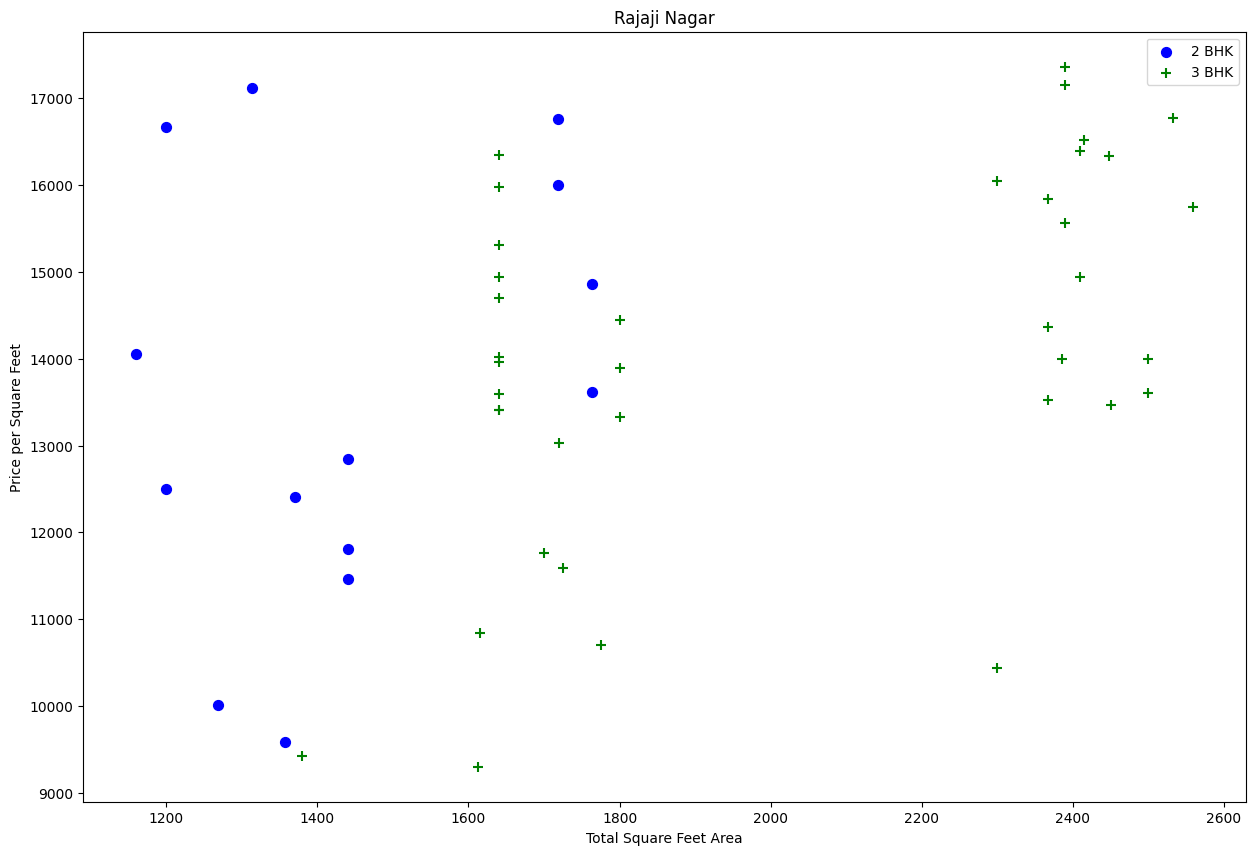

In [43]:
plot_scatter_area_bhk(df2,"Rajaji Nagar" )

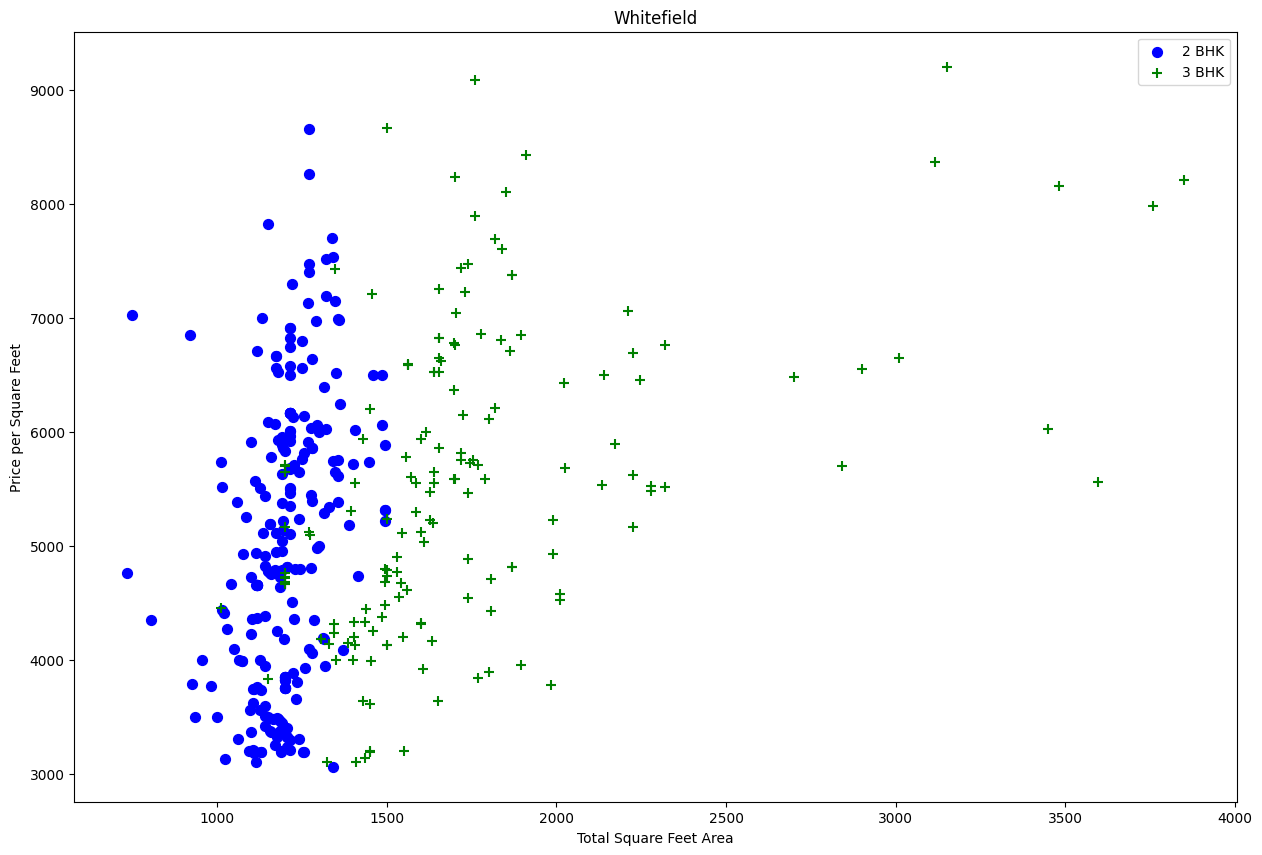

In [44]:
plot_scatter_area_bhk(df2, "Whitefield")

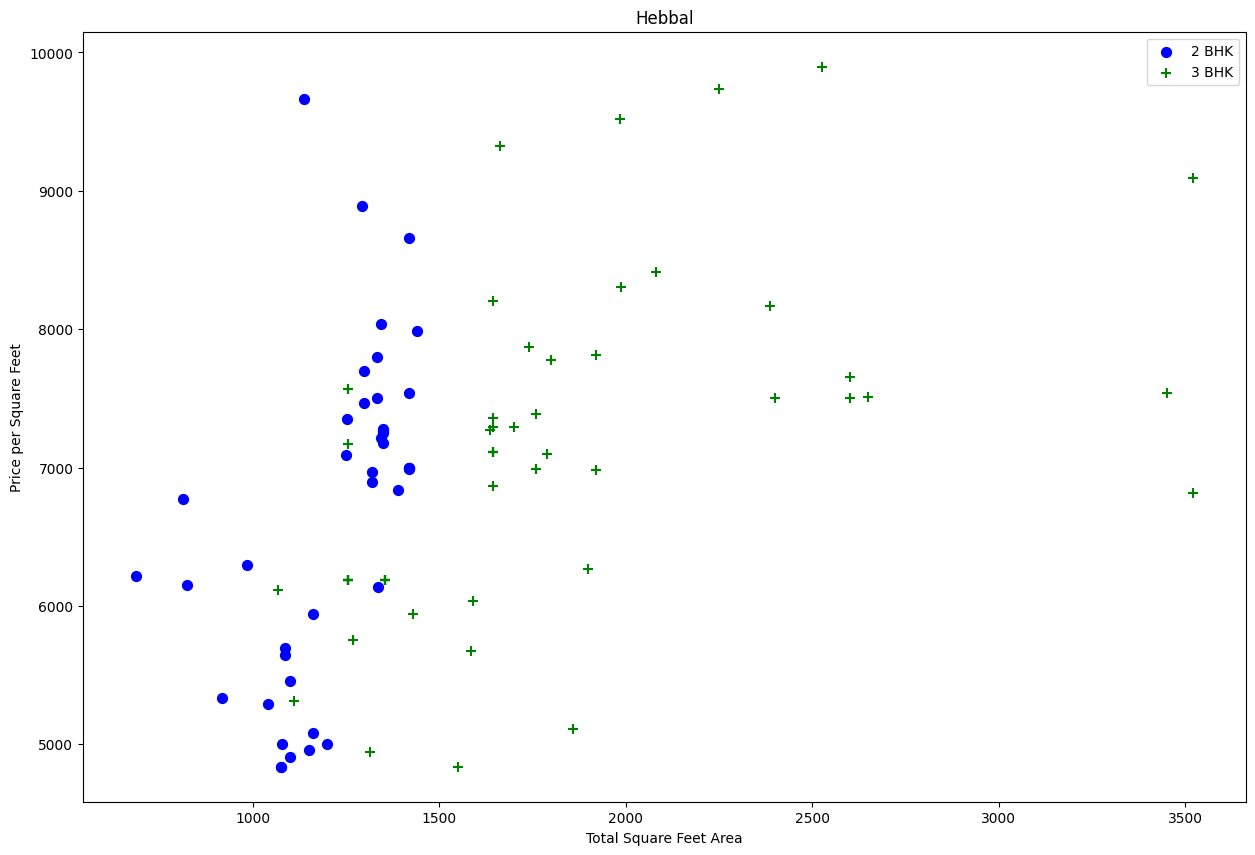

In [45]:
plot_scatter_area_bhk(df2, "Hebbal")

In [46]:
def remove_bhk_outliers(df):
  exclude_indices = np.array([])
  for location, location_df in df.groupby('location'):
    bhk_stats = {}
    for bhk, bhk_df in location_df.groupby('bhk'):
      bhk_stats[bhk] = {
          'mean' : np.mean(bhk_df.price_per_sqft),
          'std' : np.std(bhk_df.price_per_sqft),
          'count' : bhk_df.shape[0]
      }
    for bhk, bhk_df in location_df.groupby('bhk'):
      stats = bhk_stats.get(bhk - 1)
      if stats and stats['count']> 5:
        exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft < (stats['mean'])].index.values)
  return df.drop(exclude_indices, axis = 0)

In [47]:
df3 = remove_bhk_outliers(df2)
df3

,location,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,2850.0,4.0,428.0,4,15017.54
1,1st Block Jayanagar,1630.0,3.0,194.0,3,11901.84
2,1st Block Jayanagar,1875.0,2.0,235.0,3,12533.33
3,1st Block Jayanagar,1200.0,2.0,130.0,3,10833.33
4,1st Block Jayanagar,1235.0,2.0,148.0,2,11983.81
...,...,...,...,...,...,...
10230,Yeshwanthpur,1195.0,2.0,100.0,2,8368.20
10231,Yeshwanthpur,1692.0,3.0,108.0,3,6382.98
10233,Yeshwanthpur,2500.0,5.0,185.0,6,7400.00
10238,Yeshwanthpur,1855.0,3.0,135.0,3,7277.63


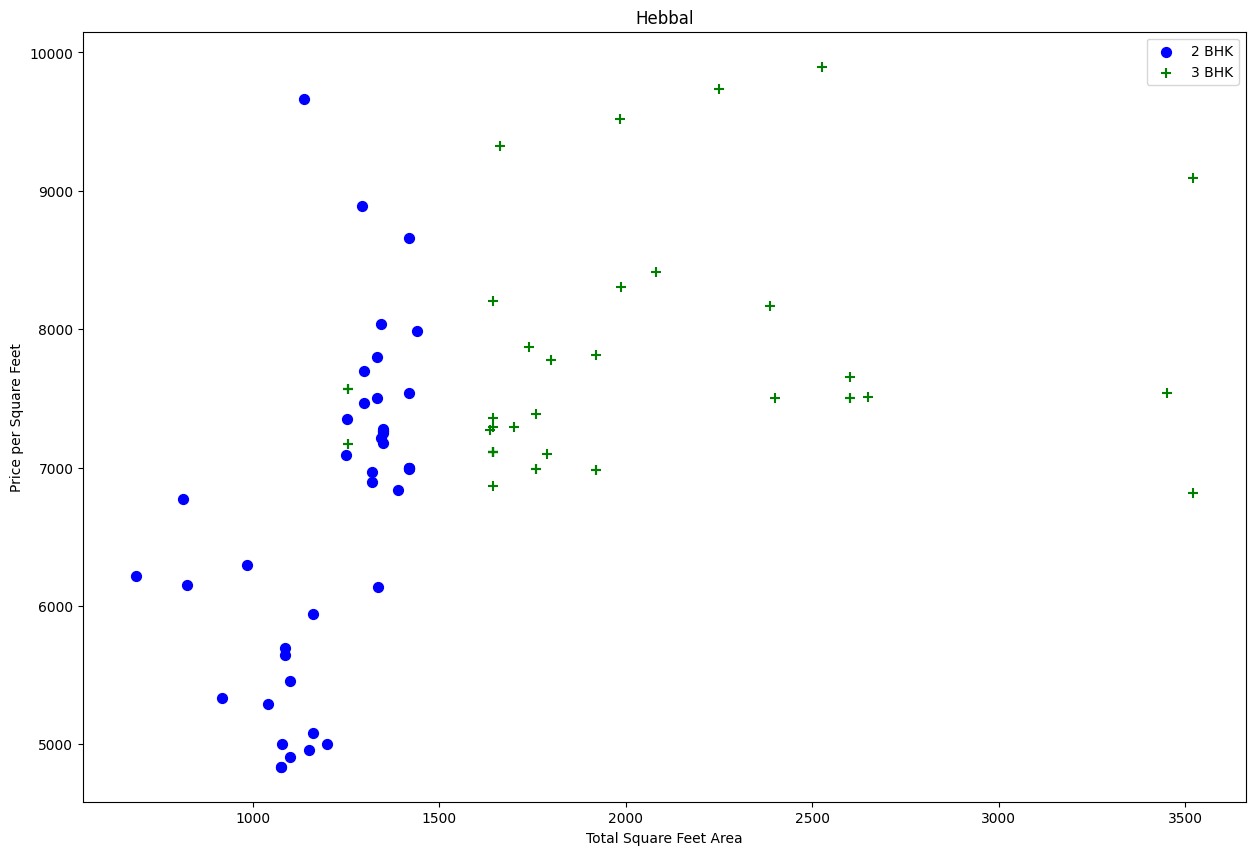

In [48]:
plot_scatter_area_bhk(df3, "Hebbal")

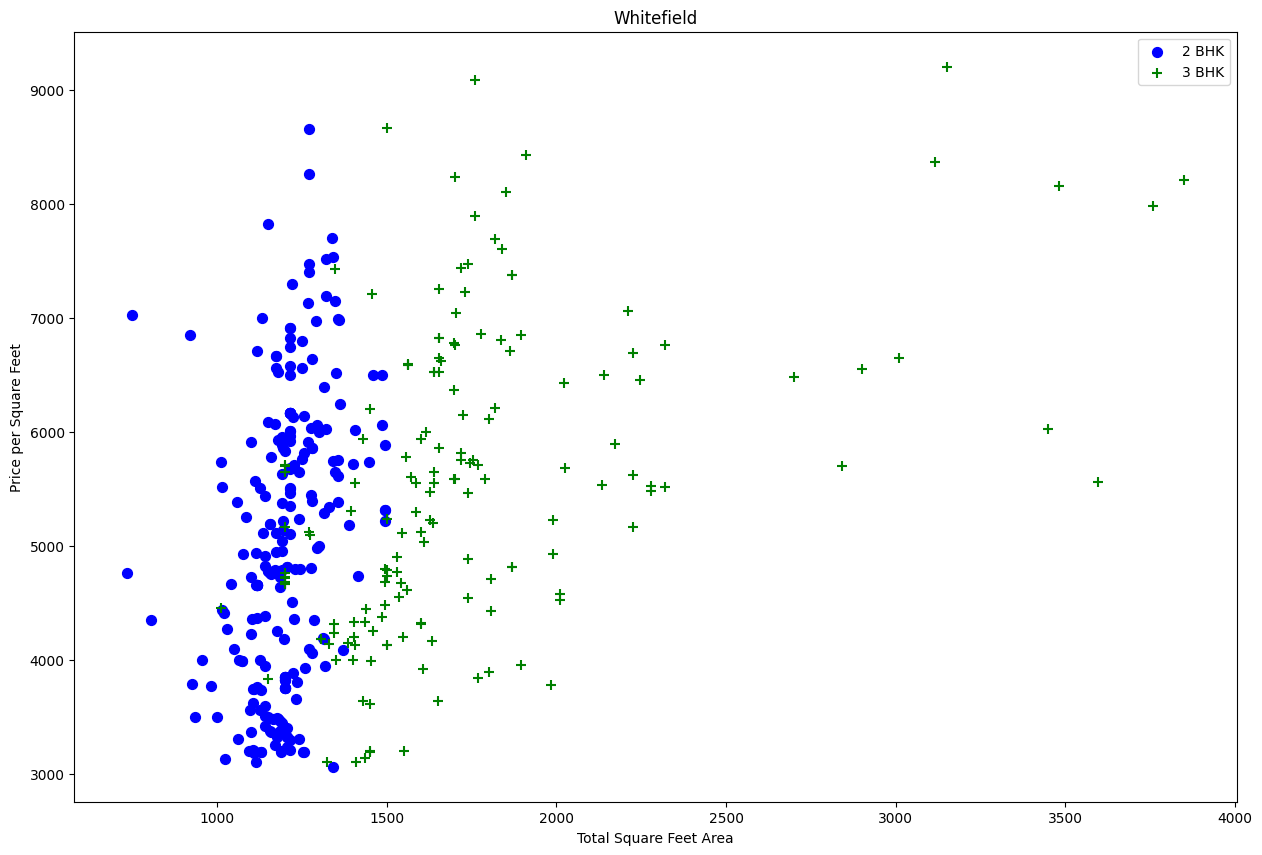

In [49]:
plot_scatter_area_bhk(df2, "Whitefield")

Text(0, 0.5, 'Count')

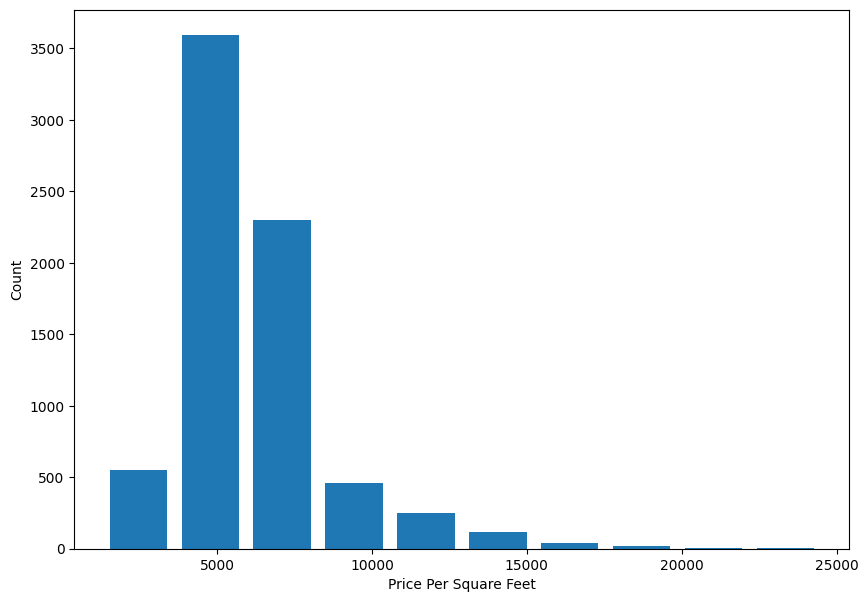

In [50]:
# Number of houses in a price range
plt.figure(figsize= (10, 7))
plt.hist(df3.price_per_sqft, rwidth = 0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

In [51]:
df3.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [52]:
df3[df3.bath > 10]

,location,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,4000.0,12.0,160.0,10,4000.00
5925,Other,12000.0,12.0,525.0,10,4375.00
6014,Other,10000.0,16.0,550.0,16,5500.00
6747,Other,6000.0,12.0,150.0,11,2500.00
7078,Other,5425.0,13.0,275.0,13,5069.12


Text(0, 0.5, 'Count')

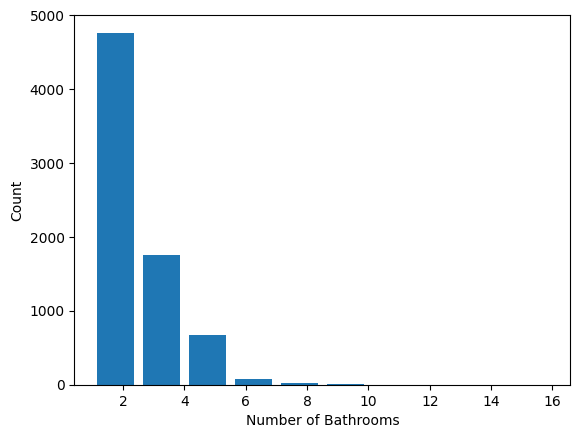

In [53]:
# Plot to count the number of Bathrroms
plt.hist(df3.bath, rwidth = 0.8)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")

In [54]:
df3[df3.bath > df3.bhk + 2]

,location,total_sqft,bath,price,bhk,price_per_sqft
1626,Chikkabanavar,2460.0,7.0,80.0,4,3252.03
5238,Nagasandra,7000.0,8.0,450.0,4,6428.57
5850,Other,11338.0,9.0,1000.0,6,8819.90
9012,Thanisandra,1806.0,6.0,116.0,3,6423.03


In [55]:
df4 = df3[df3.bath < (df3.bhk + 2)]

In [56]:
df4

,location,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,2850.0,4.0,428.0,4,15017.54
1,1st Block Jayanagar,1630.0,3.0,194.0,3,11901.84
2,1st Block Jayanagar,1875.0,2.0,235.0,3,12533.33
3,1st Block Jayanagar,1200.0,2.0,130.0,3,10833.33
4,1st Block Jayanagar,1235.0,2.0,148.0,2,11983.81
...,...,...,...,...,...,...
10230,Yeshwanthpur,1195.0,2.0,100.0,2,8368.20
10231,Yeshwanthpur,1692.0,3.0,108.0,3,6382.98
10233,Yeshwanthpur,2500.0,5.0,185.0,6,7400.00
10238,Yeshwanthpur,1855.0,3.0,135.0,3,7277.63


In [57]:
df4 = df4.drop(['price_per_sqft'], axis = 1)
df4

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2
...,...,...,...,...,...
10230,Yeshwanthpur,1195.0,2.0,100.0,2
10231,Yeshwanthpur,1692.0,3.0,108.0,3
10233,Yeshwanthpur,2500.0,5.0,185.0,6
10238,Yeshwanthpur,1855.0,3.0,135.0,3


# Model Building

As machine learning algorithms cannot process text data, we will convert them them into numeric values using one-hot encoding.

In this case `.get_dummies()`.

In [58]:
df4.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [67]:
df4[df4["location"] == "Other"]

,location,total_sqft,bath,price,bhk
5379,Other,2770.0,4.0,290.0,3
5382,Other,600.0,1.0,38.0,1
5385,Other,1500.0,2.0,185.0,2
5386,Other,840.0,2.0,45.0,2
5387,Other,4395.0,3.0,240.0,3
...,...,...,...,...,...
7671,Other,1200.0,2.0,70.0,2
7672,Other,1800.0,1.0,200.0,1
7675,Other,1353.0,2.0,110.0,2
7676,Other,812.0,1.0,26.0,1


In [60]:
dummies = pd.get_dummies(df4.location)
dummies

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10231,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10233,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10238,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


To negate the [dummy variable trap](https://www.learndatasci.com/glossary/dummy-variable-trap/), we delete a column from dummies table.

In [74]:
df5 = pd.concat([df4, dummies.drop(['Other'], axis = 1)], axis = 1)
df5

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.0,3.0,194.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.0,2.0,235.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.0,2.0,130.0,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.0,2.0,148.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,Yeshwanthpur,1195.0,2.0,100.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10231,Yeshwanthpur,1692.0,3.0,108.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10233,Yeshwanthpur,2500.0,5.0,185.0,6,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10238,Yeshwanthpur,1855.0,3.0,135.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [75]:
# now we don't need location column

df_5nal = df5.drop('location', axis = 1)
df_5nal

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,194.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,235.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,130.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,148.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,1195.0,2.0,100.0,2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10231,1692.0,3.0,108.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10233,2500.0,5.0,185.0,6,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10238,1855.0,3.0,135.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [77]:
# Create X and y variables
X = df_5nal.drop('price', axis = 1)
y = df_5nal.price

X

,total_sqft,bath,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,4,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,1195.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10231,1692.0,3.0,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10233,2500.0,5.0,6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10238,1855.0,3.0,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [78]:
y

,price
0,428.0
1,194.0
2,235.0
3,130.0
4,148.0
...,...
10230,100.0
10231,108.0
10233,185.0
10238,135.0


## Divide our data into train test split

In [79]:
from sklearn.model_selection import train_test_split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5800, 244), (1451, 244), (5800,), (1451,))

## Linear Regression

In [82]:
from sklearn.linear_model import LinearRegression

In [84]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)

0.8108830052514162

81% accuracy

## K-fold Cross validation

In [86]:
from sklearn.model_selection import ShuffleSplit, cross_val_score

cv = ShuffleSplit(n_splits = 5, test_size= 0.2, random_state = 42)

cross_val_score(LinearRegression(), X, y, cv= cv)

array([0.81088301, 0.87842769, 0.86070329, 0.87859864, 0.84660424])

## Grid Search CV

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

In [95]:
def find_best_model(X, y):

    models = {
        'linear_regression': (LinearRegression(), {
            'fit_intercept': [True, False]
        }),

        'lasso': (Lasso(), {
            'alpha': [1, 2],
            'selection': ['random', 'cyclic']
        }),

        'decision_tree': (DecisionTreeRegressor(), {
            'criterion': ['squared_error', 'friedman_mse'],
            'splitter': ['best', 'random']
        })
    }

    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

    scores = []

    for name, (model, params) in models.items():
        gs = GridSearchCV(model, params, cv=cv)
        gs.fit(X, y)

        scores.append({
            "model": name,
            "best_score": gs.best_score_,
            "best_params": gs.best_params_
        })

    return pd.DataFrame(scores)

In [96]:
find_best_model(X, y)

,model,best_score,best_params
0,linear_regression,0.855409,{'fit_intercept': False}
1,lasso,0.721939,"{'alpha': 1, 'selection': 'cyclic'}"
2,decision_tree,0.735518,"{'criterion': 'squared_error', 'splitter': 'be..."


Linear Regression is still better

# Prediction

In [108]:
X.columns

Index(['total_sqft', 'bath', 'bhk', '1st Block Jayanagar',
       '1st Phase JP Nagar', '2nd Phase Judicial Layout',
       '2nd Stage Nagarbhavi', '5th Block Hbr Layout', '5th Phase JP Nagar',
       '6th Phase JP Nagar',
       ...
       'Vijayanagar', 'Vishveshwarya Layout', 'Vishwapriya Layout',
       'Vittasandra', 'Whitefield', 'Yelachenahalli', 'Yelahanka',
       'Yelahanka New Town', 'Yelenahalli', 'Yeshwanthpur'],
      dtype='object', length=244)

In [104]:
np.where(X.columns == '2nd Phase Judicial Layout')[0][0]

np.int64(5)

5th column

In [107]:
x = np.zeros(len(X.columns))
x.shape

(244,)

In [97]:
def predict_price(location, sqft, bath, bhk):
  loc_index = np.where(X.columns == location)[0][0]

  x = np.zeros(len(X.columns))
  x[0] =sqft
  x[1] = bath
  x[2] = bhk

  if loc_index >= 0:
    x[loc_index] = 1

  return lr.predict([x])[0]

In [111]:
predict_price('1st Phase JP Nagar', 1000, 2, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(95.3292382352697)

In [117]:
predict_price(location = '1st Phase JP Nagar', sqft = 1000, bath = 5, bhk =3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(100.98729920182589)

In [115]:
predict_price('Indira Nagar', 1000, 2, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(153.55508748625425)

In [118]:
predict_price('Indira Nagar', 1000, 3, 3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(153.6058732397389)

# Export this model (.pkl)

In [121]:
import pickle
with open('banglore_house_price_model.pkl', 'wb') as f:
  pickle.dump(lr, f)

# Export the columns

In [122]:
import json

In [123]:
columns = {
    'data_cols' : [col.lower() for col in X.columns]
}

columns

{'data_cols': ['total_sqft',
  'bath',
  'bhk',
  '1st block jayanagar',
  '1st phase jp nagar',
  '2nd phase judicial layout',
  '2nd stage nagarbhavi',
  '5th block hbr layout',
  '5th phase jp nagar',
  '6th phase jp nagar',
  '7th phase jp nagar',
  '8th phase jp nagar',
  '9th phase jp nagar',
  'aecs layout',
  'abbigere',
  'akshaya nagar',
  'ambalipura',
  'ambedkar nagar',
  'amruthahalli',
  'anandapura',
  'ananth nagar',
  'anekal',
  'anjanapura',
  'ardendale',
  'arekere',
  'attibele',
  'beml layout',
  'btm 2nd stage',
  'btm layout',
  'babusapalaya',
  'badavala nagar',
  'balagere',
  'banashankari',
  'banashankari stage ii',
  'banashankari stage iii',
  'banashankari stage v',
  'banashankari stage vi',
  'banaswadi',
  'banjara layout',
  'bannerghatta',
  'bannerghatta road',
  'basavangudi',
  'basaveshwara nagar',
  'battarahalli',
  'begur',
  'begur road',
  'bellandur',
  'benson town',
  'bharathi nagar',
  'bhoganhalli',
  'billekahalli',
  'binny pete

In [124]:
with open("columns.json", 'w') as f:
  f.write(json.dumps(columns))